In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv(r"C:\Users\Zenil\Desktop\EDA Project 1 Everyday\Fertility_Health_Dataset_2026.csv")

In [3]:
dataset

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,NaN,75.7,74.1,13,NaN,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,Regular,No,High,No,Moderate,109.5,34.0,27,NaN,Success
796,797,29,26,19.1,Regular,Yes,Low,No,NaN,74.5,70.1,28,NaN,Success
797,798,38,33,26.8,Irregular,No,High,Yes,NaN,65.7,42.0,16,NaN,Success
798,799,36,33,20.6,Irregular,No,High,No,High,69.1,41.4,33,NaN,Failure


In [4]:
dataset.head()

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,NaN,75.7,74.1,13,NaN,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success


In [5]:
dataset.shape

(800, 14)

In [6]:
dataset.columns.values

<StringArray>
[                 'Couple_ID',                 'Female_Age',
                   'Male_Age',                        'BMI',
       'Menstrual_Regularity',                       'PCOS',
               'Stress_Level',                    'Smoking',
             'Alcohol_Intake', 'Sperm_Count_Million_per_ml',
                 'Motility_%',     'Trying_Duration_Months',
             'Treatment_Type',          'Pregnancy_Outcome']
Length: 14, dtype: str

In [7]:
dataset.describe()

,Couple_ID,Female_Age,Male_Age,BMI,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,31.907500,35.255000,26.647000,61.072000,54.955000,18.308750
std,231.0844,7.461806,8.216865,4.996724,34.207898,19.767997,9.958156
min,1.0000,20.000000,22.000000,18.100000,5.100000,20.100000,1.000000
25%,200.7500,25.000000,28.000000,22.100000,30.600000,38.275000,10.000000
50%,400.5000,32.000000,35.000000,26.800000,61.050000,55.550000,18.000000
75%,600.2500,39.000000,43.000000,31.000000,90.825000,71.100000,27.000000
max,800.0000,44.000000,49.000000,35.000000,119.900000,90.000000,35.000000


### Does Stress Increase with Age for Females .? (based on above dataset)

* So we can conclude that there is not much of a relation between age and stress level in females in above dataset

In [8]:
dataset.groupby("Stress_Level")["Female_Age"].mean()

Stress_Level
High      32.006993
Low       32.083004
Medium    31.628352
Name: Female_Age, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

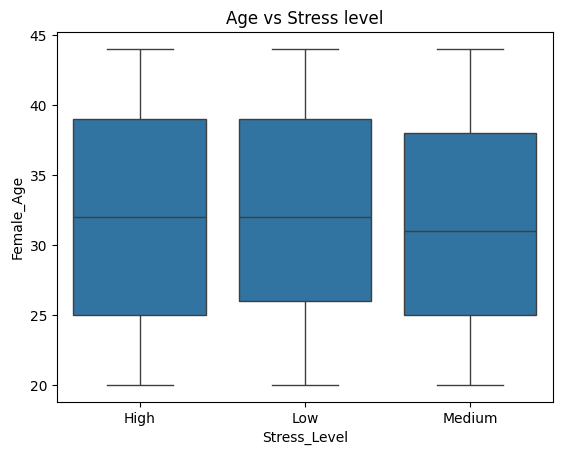

In [9]:
sns.boxplot(x="Stress_Level", y="Female_Age", data=dataset)
plt.title("Age vs Stress level")
plt.show

### Let's Now calculate same for Males 


In [10]:
dataset.groupby("Stress_Level")["Male_Age"].mean()

Stress_Level
High      34.874126
Low       35.399209
Medium    35.532567
Name: Male_Age, dtype: float64

### Again there is no Direct Co relation of age and stress level lets confirm this by pandas

In [11]:
## Bin the male age into 5-Year Groups (handles duplicate age values) 

dataset["Male_Age"].min()
#

np.int64(22)

In [12]:
bins   = [19, 24, 29, 34, 39, 44, 49]
labels = ["20–24", "25–29", "30–34", "35–39", "40–44", "45–49"]

dataset["Age_Group"] = pd.cut(dataset["Male_Age"], bins=bins, labels=labels)


In [13]:
stress_counts = dataset.groupby(["Age_Group", "Stress_Level"], observed=True).size().reset_index(name="Count") ## Observed = True gives us only combinations that exists in the data

In [14]:
stress_counts["Total"] = stress_counts.groupby("Age_Group")["Count"].transform("sum")

In [15]:
stress_counts

,Age_Group,Stress_Level,Count,Total
0,20–24,High,43,95
1,20–24,Low,27,95
2,20–24,Medium,25,95
3,25–29,High,44,155
4,25–29,Low,58,155
5,25–29,Medium,53,155
6,30–34,High,54,127
7,30–34,Low,31,127
8,30–34,Medium,42,127
9,35–39,High,46,130


In [16]:
stress_counts["Percent"] = (stress_counts["Count"]/stress_counts["Total"]*100).round(2)

In [17]:
stress_counts

,Age_Group,Stress_Level,Count,Total,Percent
0,20–24,High,43,95,45.26
1,20–24,Low,27,95,28.42
2,20–24,Medium,25,95,26.32
3,25–29,High,44,155,28.39
4,25–29,Low,58,155,37.42
5,25–29,Medium,53,155,34.19
6,30–34,High,54,127,42.52
7,30–34,Low,31,127,24.41
8,30–34,Medium,42,127,33.07
9,35–39,High,46,130,35.38


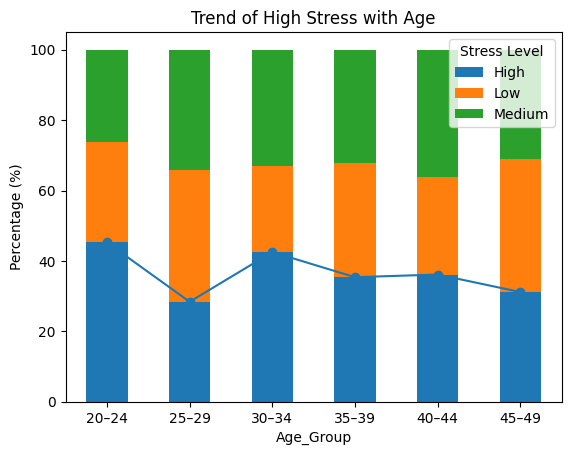

<Figure size 640x480 with 0 Axes>

In [18]:
# Pivot for plotting
pivot_df = stress_counts.pivot(
    index="Age_Group",
    columns="Stress_Level",
    values="Percent"
)

# Plot
pivot_df.plot(kind="bar", stacked=True)

plt.title("Stress Level Distribution by Age Group (Male)")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.legend(title="Stress Level")
plt.xticks(rotation=45)
pivot_df["High"].plot(marker='o')
plt.title("Trend of High Stress with Age")
plt.ylabel("Percentage (%)")
plt.show()

plt.tight_layout()
plt.show();

### Inference

“The relationship between age and stress is not linear. While some age groups show higher stress levels, the trend fluctuates rather than consistently increasing. This suggests that age alone does not significantly determine stress levels, and other factors such as lifestyle, work pressure, or personal circumstances may play a more important role.”

“We should perform a statistical test like Chi-square to confirm if the relationship is significant.”

### Now let us see if there is any direct relation between Alcohol Intake and Pregnency Outcome

In [19]:
dataset["Alcohol_Intake"] = dataset["Alcohol_Intake"].fillna("Unknown")

In [20]:
dataset

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Age_Group
0,1,26,35,22.6,Regular,No,High,No,Unknown,75.7,74.1,13,NaN,Success,35–39
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure,30–34
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success,35–39
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success,20–24
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success,40–44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,Regular,No,High,No,Moderate,109.5,34.0,27,NaN,Success,35–39
796,797,29,26,19.1,Regular,Yes,Low,No,Unknown,74.5,70.1,28,NaN,Success,25–29
797,798,38,33,26.8,Irregular,No,High,Yes,Unknown,65.7,42.0,16,NaN,Success,30–34
798,799,36,33,20.6,Irregular,No,High,No,High,69.1,41.4,33,NaN,Failure,30–34


In [21]:
pd.crosstab(dataset["Alcohol_Intake"], dataset["Stress_Level"])

Stress_Level,High,Low,Medium
Alcohol_Intake,,,
High,92,77,75
Moderate,93,105,99
Unknown,101,71,87


### Now this could be the case of MNAR — Missing Not At Random (MOST IMPORTANT 💀)

Which means it could be possible that people who take alcohol does not disclose this and hence

“The missing values in Alcohol Intake are likely MNAR since this is a sensitive behavioral variable. Therefore, instead of imputing, I treated missing values as a separate category to preserve underlying patterns.”

In [22]:
dataset

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome,Age_Group
0,1,26,35,22.6,Regular,No,High,No,Unknown,75.7,74.1,13,NaN,Success,35–39
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure,30–34
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success,35–39
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success,20–24
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success,40–44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,29,39,28.4,Regular,No,High,No,Moderate,109.5,34.0,27,NaN,Success,35–39
796,797,29,26,19.1,Regular,Yes,Low,No,Unknown,74.5,70.1,28,NaN,Success,25–29
797,798,38,33,26.8,Irregular,No,High,Yes,Unknown,65.7,42.0,16,NaN,Success,30–34
798,799,36,33,20.6,Irregular,No,High,No,High,69.1,41.4,33,NaN,Failure,30–34


### Now Let us check if Smoking Affect Menstrual Regularity in Females or not

In [23]:
pd.crosstab(dataset["Smoking"], dataset["Menstrual_Regularity"])

Menstrual_Regularity,Irregular,Regular
Smoking,,
No,165,375
Yes,76,184


In [24]:
from scipy.stats import chi2_contingency

table = pd.crosstab(dataset["Smoking"], dataset["Menstrual_Regularity"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 0.09015705984953037
p-value: 0.7639775814494577


### 
As our P-value is > 0.05

“There is no statistically significant relationship between smoking and menstrual regularity. Any observed differences could be due to random variation.”



### “Both statistical testing (Chi-square) and proportion comparison show negligible difference, indicating that smoking does not have a significant association with menstrual regularity in this dataset.”

### Now this above analysis is wrong as we do not know if smoking is done by a male or a female. and hence data is ambigious

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [35]:
features = [
    "Female_Age",
    "Male_Age",
    "BMI",
    "Menstrual_Regularity",
    "PCOS",
    "Stress_Level",
    "Smoking",
    "Alcohol_Intake",
    "Sperm_Count_Million_per_ml"
]

target = "Pregnancy_Outcome"

X = dataset[features]
y = dataset[target]

In [36]:
X

,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml
0,26,35,22.6,Regular,No,High,No,Unknown,75.7
1,39,30,28.0,Regular,No,High,Yes,Moderate,25.2
2,34,35,24.1,Regular,Yes,Low,No,High,64.0
3,30,22,19.6,Regular,No,High,No,High,87.3
4,27,40,33.6,Irregular,No,Low,No,High,116.9
...,...,...,...,...,...,...,...,...,...
795,29,39,28.4,Regular,No,High,No,Moderate,109.5
796,29,26,19.1,Regular,Yes,Low,No,Unknown,74.5
797,38,33,26.8,Irregular,No,High,Yes,Unknown,65.7
798,36,33,20.6,Irregular,No,High,No,High,69.1


In [40]:
y.value_counts()

Pregnancy_Outcome
Success    582
Failure    218
Name: count, dtype: int64